# 多数据集基因表达预测结果分析

分析三个数据集的模型表现，重点关注基因覆盖率与预测性能的关系。

**章节：**
1. Setup & 加载结果
2. 汇总表格（所有实验）
3. 关键对比：MorphPT vs DINOv3
4. 基因覆盖率分布（三个数据集）
5. 覆盖率分层性能分析
6. 每个数据集的per-gene Pearson r分布
7. 关键模型对的per-gene delta分析

## 1. Setup & 加载结果

In [1]:
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

PROJECT  = Path('/hpc/group/jilab/tc459/MorphPT')
EXP_DIR  = PROJECT / 'experiments'

CACHE = {
    'crc':      PROJECT / 'cache_crc',
    'lung':     PROJECT / 'cache_lung',
    'pancreas': PROJECT / 'cache_pancreas',
}

COLORS = {
    'crc':      '#C44E52',
    'lung':     '#4C72B0',
    'pancreas': '#55A868',
}
LABELS = {
    'crc':      'CRC (2,220 genes)',
    'lung':     'Lung Cancer (1,197 genes)',
    'pancreas': 'Pancreas (501 genes)',
}

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})
print('Setup done.')

Setup done.


In [2]:
def load_all_results():
    results = []
    for d in sorted(EXP_DIR.glob('visium_*')):
        f = d / 'test_results.json'
        if not f.exists():
            continue
        r = json.loads(f.read_text())
        name = d.name

        # Infer dataset
        if '_pancreas' in name:   dataset = 'pancreas'
        elif '_lung' in name:     dataset = 'lung'
        elif '_crc' in name:      dataset = 'crc'
        else:                     dataset = 'crc_old'

        split = 'random' if 'randsplit' in name else 'spatial'

        # Infer model config
        morphpt = 'dinov3' not in name
        lora    = 'lora' in name
        gate    = 'gate' in name
        scale   = '25x' if '25x' in name else '10x'
        mixloss = 'mixloss' in name

        results.append({
            'name':     name,
            'dataset':  dataset,
            'split':    split,
            'morphpt':  morphpt,
            'lora':     lora,
            'gate':     gate,
            'scale':    scale,
            'mixloss':  mixloss,
            'mean_r':   r.get('test_mean_pearson', 0),
            'median_r': r.get('test_median_pearson', 0),
            'val_r':    r.get('best_val_pearson', 0),
            'zMSE':     r.get('test_zMSE', 0),
            'exp_dir':  d,
        })
    return pd.DataFrame(results)

df_all = load_all_results()
print(f'Total experiments: {len(df_all)}')
print(f'Datasets: {df_all["dataset"].value_counts().to_dict()}')

Total experiments: 48
Datasets: {'crc_old': 15, 'crc': 11, 'lung': 11, 'pancreas': 11}


## 2. 汇总表格

In [3]:
# 随机split结果（主要结果）
df_rand = df_all[df_all['split'] == 'random'].sort_values(
    ['dataset', 'mean_r'], ascending=[True, False]
).reset_index(drop=True)

print('=== 随机Split结果 ===')
print(f"{' Name':<55} {'dataset':<10} {'mean_r':>8} {'val_r':>8} {'zMSE':>8}")
print('-' * 95)
for _, row in df_rand.iterrows():
    flag = ' ← BAD' if row['zMSE'] > 1.0 else ''
    print(f"{row['name']:<55} {row['dataset']:<10} "
          f"{row['mean_r']:>8.4f} {row['val_r']:>8.4f} "
          f"{row['zMSE']:>8.4f}{flag}")

=== 随机Split结果 ===
 Name                                                   dataset      mean_r    val_r     zMSE
-----------------------------------------------------------------------------------------------
visium_morphpt_lora_gate_mlp_crc_randsplit              crc          0.2081   0.2079   0.9454
visium_morphpt_lora_10x_mlp_mixloss_crc_randsplit       crc          0.2070   0.2066   0.9459
visium_morphpt_lora_10x_mlp_crc_randsplit               crc          0.2069   0.2066   0.9458
visium_dinov3_lora_10x_mlp_crc_randsplit                crc          0.2055   0.2052   0.9464
visium_morphpt_lora_25x_mlp_crc_randsplit               crc          0.1927   0.1925   0.9532
visium_dinov3_lora_25x_mlp_crc_randsplit                crc          0.1916   0.1912   0.9539
visium_morphpt_lora_gate_mlp_lung_randsplit             lung         0.0845   0.0851   0.9916
visium_morphpt_lora_10x_mlp_mixloss_lung_randsplit      lung         0.0810   0.0815   0.9925
visium_morphpt_lora_10x_mlp_lung_randspl

## 3. 关键对比：MorphPT vs DINOv3


=== MorphPT vs DINOv3 (LoRA + MLP + 10×, random split) ===
Dataset          DINOv3    MorphPT        Δ
---------------------------------------------
CRC              0.2055     0.2069  +0.0014
Lung Cancer      0.0676     0.0807  +0.0131 ← significant
Pancreas         0.1280     0.1277  -0.0002


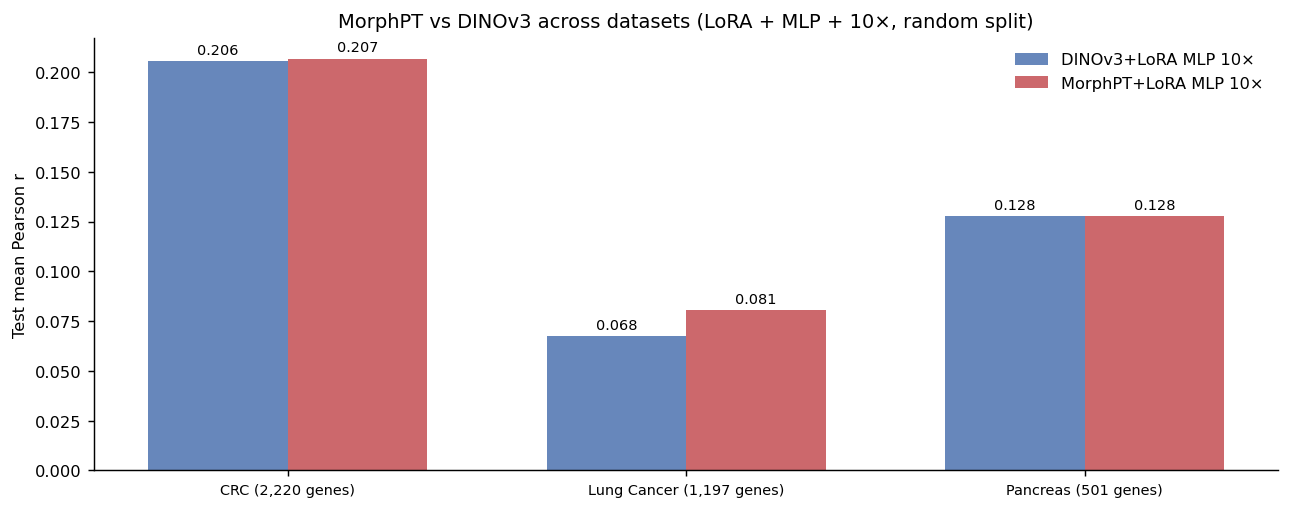

In [4]:
# 筛选关键对比: LoRA + MLP + 10x, random split, no gate, no mixloss
df_key = df_all[
    (df_all['split']   == 'random') &
    (df_all['lora']    == True) &
    (df_all['scale']   == '10x') &
    (df_all['gate']    == False) &
    (df_all['mixloss'] == False) &
    (df_all['dataset'] != 'crc_old')
].copy()

print('\n=== MorphPT vs DINOv3 (LoRA + MLP + 10×, random split) ===')
print(f"{'Dataset':<12} {'DINOv3':>10} {'MorphPT':>10} {'Δ':>8}")
print('-' * 45)

for ds in ['crc', 'lung', 'pancreas']:
    dino  = df_key[(df_key['dataset']==ds) & (df_key['morphpt']==False)]['mean_r'].values
    morph = df_key[(df_key['dataset']==ds) & (df_key['morphpt']==True)]['mean_r'].values
    if len(dino) and len(morph):
        delta = morph[0] - dino[0]
        flag  = ' ← significant' if abs(delta) > 0.01 else ''
        print(f"{LABELS[ds].split('(')[0].strip():<12} "
              f"{dino[0]:>10.4f} {morph[0]:>10.4f} {delta:>+8.4f}{flag}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
datasets = ['crc', 'lung', 'pancreas']
x        = np.arange(len(datasets))
width    = 0.35

dino_vals  = []
morph_vals = []
for ds in datasets:
    d = df_key[(df_key['dataset']==ds) & (df_key['morphpt']==False)]['mean_r'].values
    m = df_key[(df_key['dataset']==ds) & (df_key['morphpt']==True)]['mean_r'].values
    dino_vals.append(d[0] if len(d) else 0)
    morph_vals.append(m[0] if len(m) else 0)

bars1 = ax.bar(x - width/2, dino_vals,  width, label='DINOv3+LoRA MLP 10×',
               color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, morph_vals, width, label='MorphPT+LoRA MLP 10×',
               color='#C44E52', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([LABELS[d] for d in datasets], fontsize=8)
ax.set_ylabel('Test mean Pearson r')
ax.set_title('MorphPT vs DINOv3 across datasets (LoRA + MLP + 10×, random split)')
ax.legend()
fig.tight_layout()
plt.show()

In [5]:
# Scale effect: 2.5x vs 10x
df_scale = df_all[
    (df_all['split']   == 'random') &
    (df_all['lora']    == True) &
    (df_all['morphpt'] == True) &
    (df_all['gate']    == False) &
    (df_all['mixloss'] == False) &
    (df_all['dataset'] != 'crc_old')
].copy()

print('\n=== Scale Effect: 2.5× vs 10× (MorphPT+LoRA MLP, random split) ===')
print(f"{'Dataset':<12} {'2.5×':>8} {'10×':>8} {'Δ(10×-2.5×)':>12}")
print('-' * 45)
for ds in ['crc', 'lung', 'pancreas']:
    s25  = df_scale[(df_scale['dataset']==ds) & (df_scale['scale']=='25x')]['mean_r'].values
    s10  = df_scale[(df_scale['dataset']==ds) & (df_scale['scale']=='10x')]['mean_r'].values
    if len(s25) and len(s10):
        delta = s10[0] - s25[0]
        print(f"{LABELS[ds].split('(')[0].strip():<12} "
              f"{s25[0]:>8.4f} {s10[0]:>8.4f} {delta:>+12.4f}")


=== Scale Effect: 2.5× vs 10× (MorphPT+LoRA MLP, random split) ===
Dataset          2.5×      10×  Δ(10×-2.5×)
---------------------------------------------
CRC            0.1927   0.2069      +0.0142
Lung Cancer    0.0549   0.0807      +0.0258
Pancreas       0.1079   0.1277      +0.0198


## 4. 基因覆盖率分布（三个数据集）

In [6]:
def get_test_coverage(dataset):
    """计算test cells上每个基因的覆盖率"""
    cache = CACHE[dataset]
    expr  = np.load(str(cache / 'expr.npy'), mmap_mode='r')
    meta  = pd.read_csv(cache / 'meta_random_split.csv')
    test_idx = meta[meta['split'] == 'test']['mmap_idx'].values
    X_test   = expr[test_idx]
    coverage = (X_test > 0).mean(axis=0)
    genes    = (cache / 'gene_list.txt').read_text().splitlines()
    return coverage, genes

print('Loading coverage data...')
coverage_data = {}
for ds in ['crc', 'lung', 'pancreas']:
    cov, genes = get_test_coverage(ds)
    coverage_data[ds] = {'coverage': cov, 'genes': genes}
    print(f'  {ds}: {len(genes)} genes, '
          f'coverage range [{cov.min():.1%}, {cov.max():.1%}]')

Loading coverage data...
  crc: 2220 genes, coverage range [9.6%, 96.9%]
  lung: 1197 genes, coverage range [9.8%, 98.7%]
  pancreas: 501 genes, coverage range [9.3%, 99.8%]


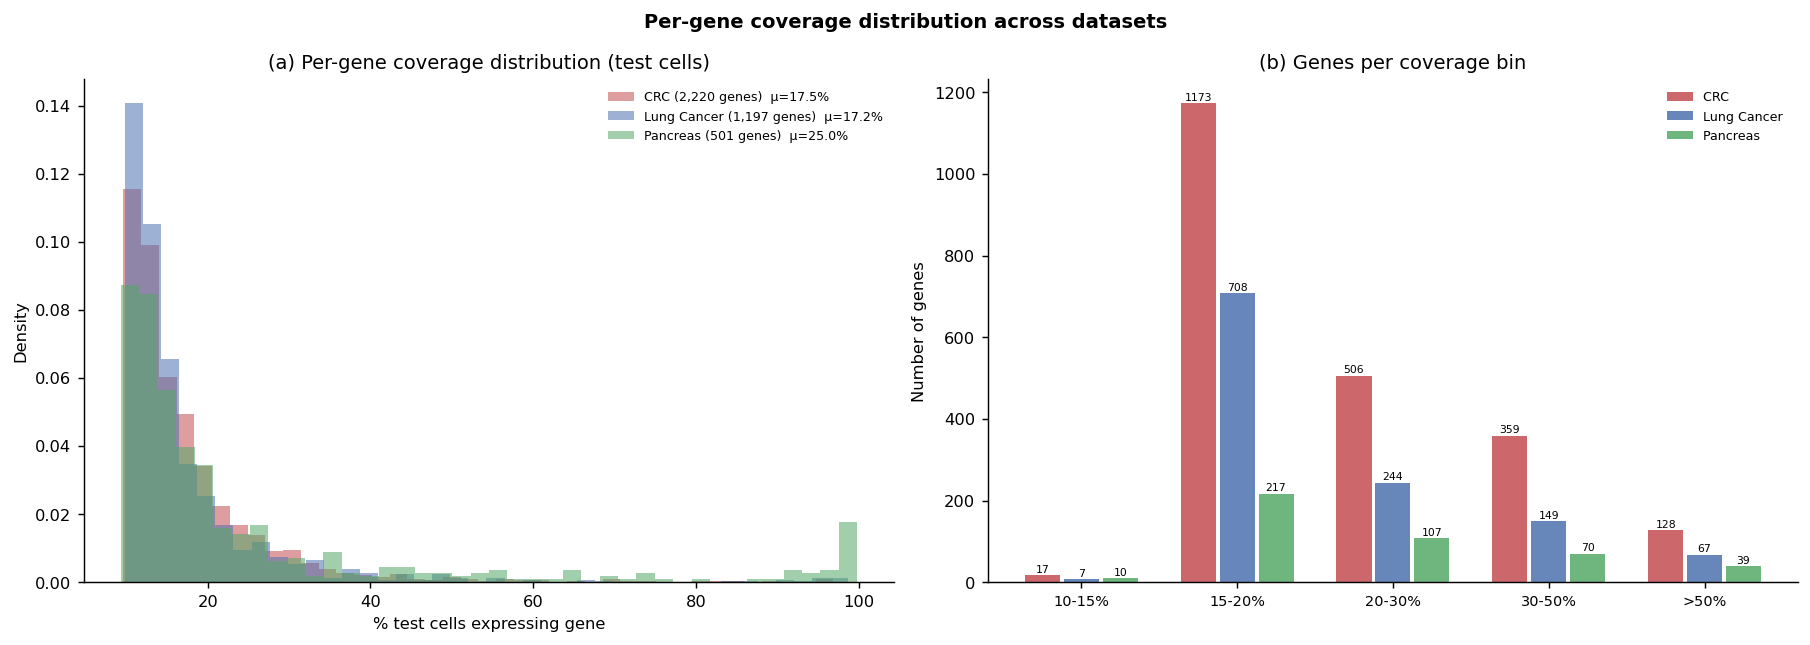

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coverage histogram
ax = axes[0]
for ds in ['crc', 'lung', 'pancreas']:
    cov = coverage_data[ds]['coverage'] * 100
    ax.hist(cov, bins=40, alpha=0.55, color=COLORS[ds],
            density=True, edgecolor='none',
            label=f"{LABELS[ds]}  μ={cov.mean():.1f}%")
ax.set_xlabel('% test cells expressing gene')
ax.set_ylabel('Density')
ax.set_title('(a) Per-gene coverage distribution (test cells)')
ax.legend(fontsize=7)

# Right: coverage bins count
ax    = axes[1]
bins  = [0, 0.10, 0.15, 0.20, 0.30, 0.50, 1.01]
blabels = ['10-15%', '15-20%', '20-30%', '30-50%', '>50%']
x     = np.arange(len(blabels))
width = 0.25

for i, ds in enumerate(['crc', 'lung', 'pancreas']):
    cov    = coverage_data[ds]['coverage']
    counts = [((cov >= bins[j]) & (cov < bins[j+1])).sum()
              for j in range(len(blabels))]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, counts, width=width*0.9,
                  color=COLORS[ds], alpha=0.85, label=LABELS[ds].split('(')[0])
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 2, str(cnt),
                    ha='center', va='bottom', fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(blabels, fontsize=8)
ax.set_ylabel('Number of genes')
ax.set_title('(b) Genes per coverage bin')
ax.legend(fontsize=7)

fig.suptitle('Per-gene coverage distribution across datasets', fontweight='bold')
fig.tight_layout()
plt.show()

## 5. 覆盖率分层性能分析

In [8]:
def load_per_gene_pearson(exp_dir):
    p = Path(exp_dir) / 'per_gene_pearson_test.pt'
    if not p.exists():
        return None
    return torch.load(p, map_location='cpu').numpy()

# 选每个数据集的最优模型 (MorphPT+LoRA MLP 10x random split)
BEST_MODELS = {
    'crc':      'visium_morphpt_lora_10x_mlp_crc_randsplit',
    'lung':     'visium_morphpt_lora_10x_mlp_lung_randsplit',
    'pancreas': 'visium_morphpt_lora_10x_mlp_pancreas_randsplit',
}

# Coverage bins
bins   = [0, 0.10, 0.15, 0.20, 0.30, 0.50, 1.01]
blabels= ['10-15%', '15-20%', '20-30%', '30-50%', '>50%']

# Compute mean Pearson per bin per dataset
heatmap_rows   = []
heatmap_labels = []

for ds in ['crc', 'lung', 'pancreas']:
    exp_dir = EXP_DIR / BEST_MODELS[ds]
    r       = load_per_gene_pearson(exp_dir)
    cov     = coverage_data[ds]['coverage']
    if r is None:
        print(f'  {ds}: per_gene_pearson_test.pt not found')
        continue
    bin_idx = np.clip(np.digitize(cov, bins) - 1, 0, len(blabels)-1)
    means   = [r[bin_idx == b].mean() if (bin_idx==b).sum()>0 else np.nan
               for b in range(len(blabels))]
    heatmap_rows.append(means)
    heatmap_labels.append(LABELS[ds].split('(')[0].strip())
    print(f'  {ds}: loaded {len(r)} gene Pearson r values')

print('Coverage-stratified analysis ready.')

  crc: loaded 2220 gene Pearson r values
  lung: loaded 1197 gene Pearson r values
  pancreas: loaded 501 gene Pearson r values
Coverage-stratified analysis ready.


/tmp/ipykernel_2565259/2736311640.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(p, map_location='cpu').numpy()


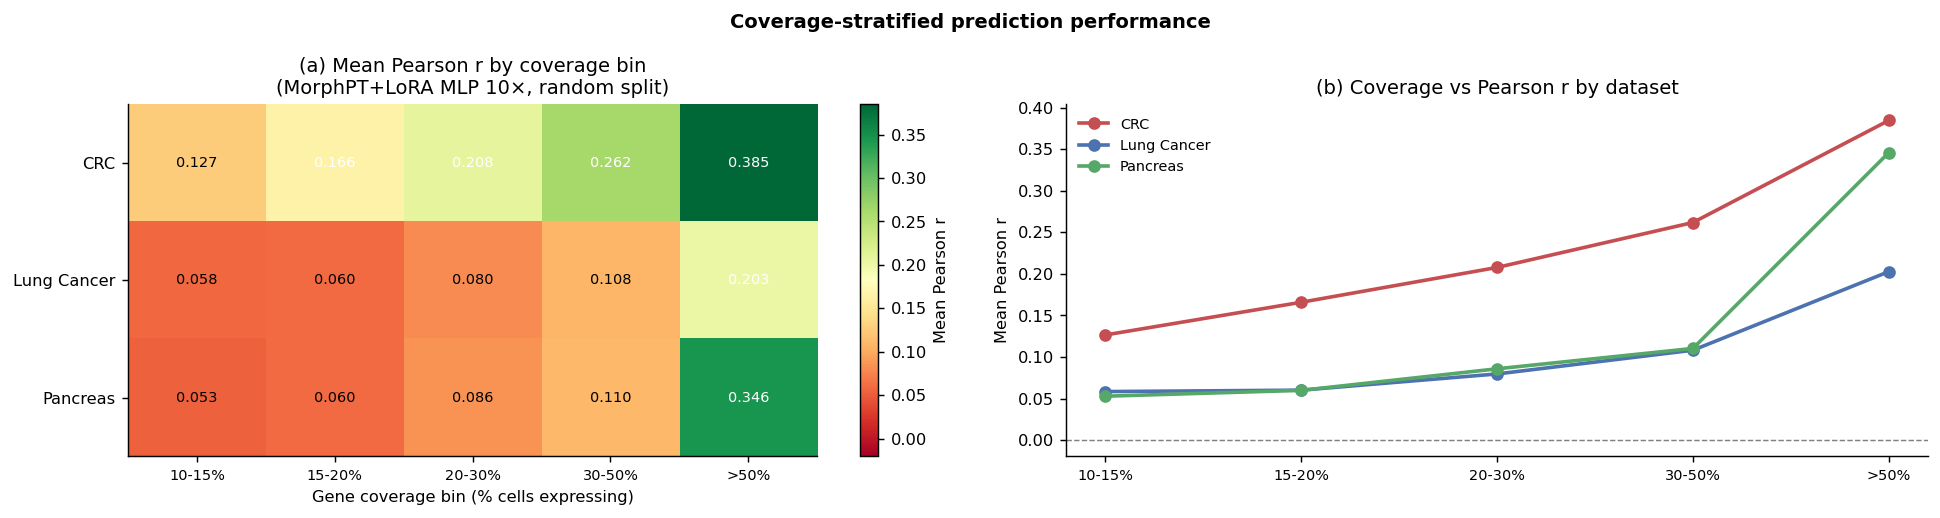

In [9]:
if heatmap_rows:
    heatmap = np.array(heatmap_rows)
    bin_counts = [
        {b: sum((np.clip(np.digitize(coverage_data[ds]['coverage'], bins)-1,
                         0, len(blabels)-1) == i).sum()
                for ds in coverage_data)
         for i, b in enumerate(blabels)}
    ]

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Left: heatmap
    ax  = axes[0]
    vmin = min(-0.02, float(np.nanmin(heatmap)))
    vmax = max(0.25,  float(np.nanmax(heatmap)))
    im   = ax.imshow(heatmap, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label='Mean Pearson r')

    # Per-dataset bin counts
    bin_count_labels = []
    for bi, bl in enumerate(blabels):
        total = sum((np.clip(np.digitize(coverage_data[ds]['coverage'], bins)-1,
                             0, len(blabels)-1) == bi).sum()
                    for ds in ['crc','lung','pancreas'])
        bin_count_labels.append(f'{bl}')

    ax.set_xticks(range(len(blabels)))
    ax.set_xticklabels(bin_count_labels, fontsize=8)
    ax.set_yticks(range(len(heatmap_labels)))
    ax.set_yticklabels(heatmap_labels, fontsize=9)
    ax.set_xlabel('Gene coverage bin (% cells expressing)')
    ax.set_title('(a) Mean Pearson r by coverage bin\n(MorphPT+LoRA MLP 10×, random split)')

    for i in range(heatmap.shape[0]):
        for j in range(heatmap.shape[1]):
            v = heatmap[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                        fontsize=8,
                        color='white' if abs(v) > 0.15 else 'black')

    # Right: line plot
    ax = axes[1]
    for i, (ds, label) in enumerate(zip(['crc','lung','pancreas'], heatmap_labels)):
        if i < len(heatmap_rows):
            ax.plot(range(len(blabels)), heatmap_rows[i],
                    marker='o', color=COLORS[ds], label=label, lw=2)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xticks(range(len(blabels)))
    ax.set_xticklabels(blabels, fontsize=8)
    ax.set_ylabel('Mean Pearson r')
    ax.set_title('(b) Coverage vs Pearson r by dataset')
    ax.legend(fontsize=8)

    fig.suptitle('Coverage-stratified prediction performance', fontweight='bold')
    fig.tight_layout()
    plt.show()

## 6. Per-gene Pearson r 分布（violin + stacked bar）

In [10]:
# 加载每个数据集最优模型的per-gene pearson
per_gene_data = {}
for ds in ['crc', 'lung', 'pancreas']:
    exp_dir = EXP_DIR / BEST_MODELS[ds]
    r = load_per_gene_pearson(exp_dir)
    if r is not None:
        per_gene_data[ds] = r
        print(f'{ds}: mean_r={r.mean():.4f}  median_r={np.median(r):.4f}  '
              f'r>0.1: {(r>0.1).sum()}/{len(r)}  '
              f'r>0.2: {(r>0.2).sum()}/{len(r)}')

crc: mean_r=0.2069  median_r=0.1801  r>0.1: 2116/2220  r>0.2: 893/2220
lung: mean_r=0.0807  median_r=0.0636  r>0.1: 232/1197  r>0.2: 55/1197
pancreas: mean_r=0.1277  median_r=0.0736  r>0.1: 178/501  r>0.2: 75/501


/tmp/ipykernel_2565259/2736311640.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(p, map_location='cpu').numpy()


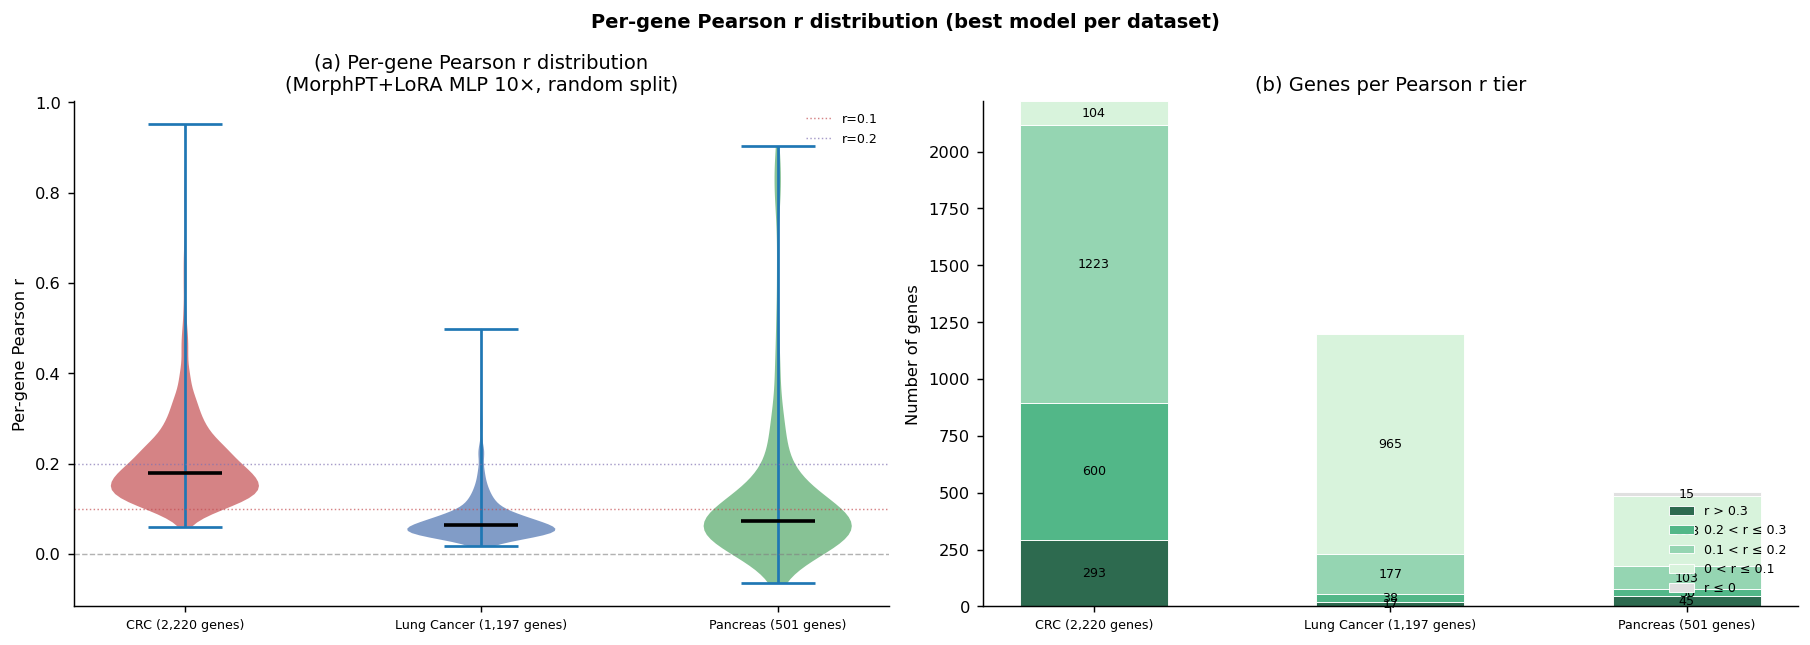

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets_with_data = [ds for ds in ['crc','lung','pancreas'] if ds in per_gene_data]
data_list  = [per_gene_data[ds] for ds in datasets_with_data]
xlabels    = [LABELS[ds] for ds in datasets_with_data]
color_list = [COLORS[ds] for ds in datasets_with_data]

# Left: violin
ax    = axes[0]
parts = ax.violinplot(data_list, positions=range(len(data_list)),
                      showmedians=True, showextrema=True)
for pc, col in zip(parts['bodies'], color_list):
    pc.set_facecolor(col)
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(data_list)))
ax.set_xticklabels(xlabels, fontsize=7)
ax.axhline(0,   color='gray',    lw=0.8, ls='--', alpha=0.6)
ax.axhline(0.1, color='#C44E52', lw=0.8, ls=':',  alpha=0.7, label='r=0.1')
ax.axhline(0.2, color='#8172B2', lw=0.8, ls=':',  alpha=0.7, label='r=0.2')
ax.set_ylabel('Per-gene Pearson r')
ax.set_title('(a) Per-gene Pearson r distribution\n(MorphPT+LoRA MLP 10×, random split)')
ax.legend(fontsize=7)

# Right: stacked bar
ax      = axes[1]
tiers   = [(0.3, 1.0, 'r > 0.3',       '#2d6a4f'),
           (0.2, 0.3, '0.2 < r ≤ 0.3', '#52b788'),
           (0.1, 0.2, '0.1 < r ≤ 0.2', '#95d5b2'),
           (0.0, 0.1, '0 < r ≤ 0.1',   '#d8f3dc'),
           (-1,  0.0, 'r ≤ 0',          '#e0e0e0')]
x       = np.arange(len(data_list))
bottoms = np.zeros(len(data_list))

for lo, hi, label, color in tiers:
    counts = np.array([int(((d > lo) & (d <= hi)).sum()) for d in data_list])
    ax.bar(x, counts, bottom=bottoms, color=color, label=label,
           width=0.5, edgecolor='white', linewidth=0.5)
    for xi, (cnt, bot) in enumerate(zip(counts, bottoms)):
        if cnt > 10:
            ax.text(xi, bot + cnt/2, str(cnt),
                    ha='center', va='center', fontsize=7)
    bottoms += counts

ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=7)
ax.set_ylabel('Number of genes')
ax.set_title('(b) Genes per Pearson r tier')
ax.legend(loc='lower right', fontsize=7)

fig.suptitle('Per-gene Pearson r distribution (best model per dataset)',
             fontweight='bold')
fig.tight_layout()
plt.show()

## 7. Per-gene Delta: MorphPT vs DINOv3

/tmp/ipykernel_2565259/2736311640.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(p, map_location='cpu').numpy()
/tmp/ipykernel_2565259/2736311640.py:5

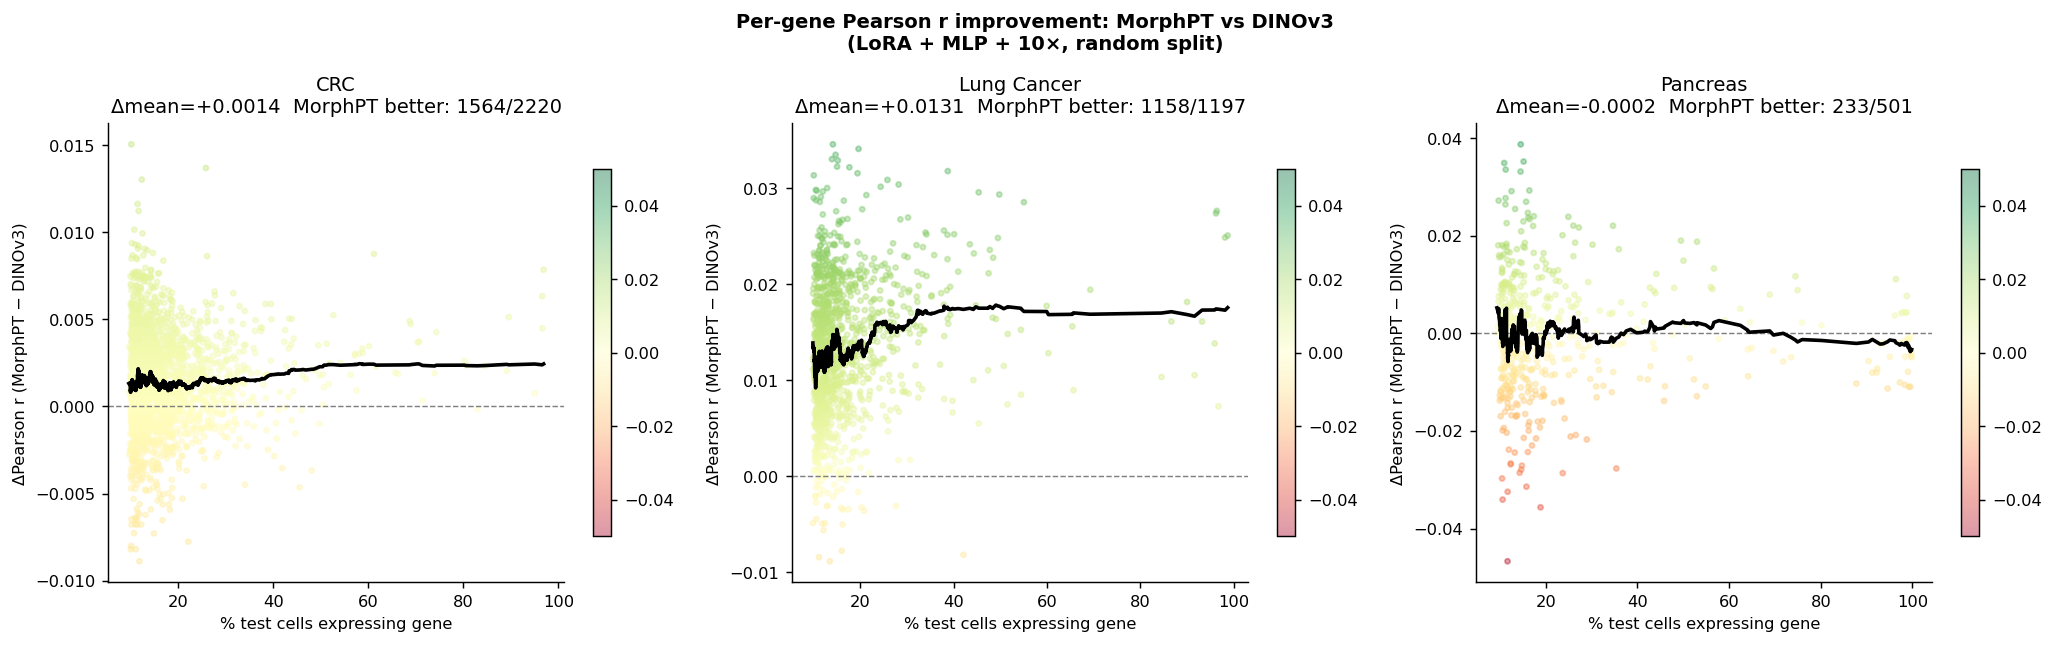

In [12]:
# 对比模型
DINO_MODELS = {
    'crc':      'visium_dinov3_lora_10x_mlp_crc_randsplit',
    'lung':     'visium_dinov3_lora_10x_mlp_lung_randsplit',
    'pancreas': 'visium_dinov3_lora_10x_mlp_pancreas_randsplit',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, ds in enumerate(['crc', 'lung', 'pancreas']):
    r_morph = load_per_gene_pearson(EXP_DIR / BEST_MODELS[ds])
    r_dino  = load_per_gene_pearson(EXP_DIR / DINO_MODELS[ds])

    if r_morph is None or r_dino is None:
        axes[i].set_visible(False)
        continue

    delta = r_morph - r_dino
    cov   = coverage_data[ds]['coverage'] * 100

    ax = axes[i]
    sc = ax.scatter(cov, delta, c=delta, cmap='RdYlGn',
                    vmin=-0.05, vmax=0.05, alpha=0.4, s=8, rasterized=True)
    ax.axhline(0, color='gray', lw=0.8, ls='--')

    # Smooth trend
    from scipy.ndimage import uniform_filter1d
    sort_idx = np.argsort(cov)
    window   = max(10, len(cov)//20)
    smooth   = uniform_filter1d(delta[sort_idx], size=window)
    ax.plot(cov[sort_idx], smooth, color='black', lw=2)

    n_better = (delta > 0).sum()
    ax.set_title(f'{LABELS[ds].split("(")[0].strip()}\n'
                 f'Δmean={delta.mean():+.4f}  '
                 f'MorphPT better: {n_better}/{len(delta)}')
    ax.set_xlabel('% test cells expressing gene')
    ax.set_ylabel('ΔPearson r (MorphPT − DINOv3)')
    plt.colorbar(sc, ax=ax, shrink=0.8)

fig.suptitle('Per-gene Pearson r improvement: MorphPT vs DINOv3\n'
             '(LoRA + MLP + 10×, random split)', fontweight='bold')
fig.tight_layout()
plt.show()

## 8. 总结

In [13]:
print('=' * 65)
print('SUMMARY — Multi-dataset gene expression prediction')
print('=' * 65)

print('\n1. Best results (MorphPT+LoRA MLP 10×, random split):')
for ds in ['crc', 'lung', 'pancreas']:
    exp = EXP_DIR / BEST_MODELS[ds]
    r   = json.loads((exp / 'test_results.json').read_text())
    pg  = load_per_gene_pearson(exp)
    cov = coverage_data[ds]['coverage']
    n   = len(cov)
    print(f'  {LABELS[ds]}:')
    print(f'    test_mean_r  = {r["test_mean_pearson"]:.4f}')
    print(f'    test_median_r= {r["test_median_pearson"]:.4f}')
    if pg is not None:
        print(f'    r>0.1: {(pg>0.1).sum():>4}/{n}  '
              f'r>0.2: {(pg>0.2).sum():>4}/{n}  '
              f'r>0.3: {(pg>0.3).sum():>4}/{n}')

print('\n2. MorphPT vs DINOv3 (LoRA + MLP + 10×, random split):')
for ds in ['crc', 'lung', 'pancreas']:
    r_m = load_per_gene_pearson(EXP_DIR / BEST_MODELS[ds])
    r_d = load_per_gene_pearson(EXP_DIR / DINO_MODELS[ds])
    if r_m is not None and r_d is not None:
        delta = r_m.mean() - r_d.mean()
        print(f'  {LABELS[ds].split("(")[0].strip():<15}: '
              f'DINOv3={r_d.mean():.4f}  '
              f'MorphPT={r_m.mean():.4f}  '
              f'Δ={delta:+.4f}')

print('\n3. Spatial vs Random split (MorphPT+LoRA MLP 10×):')
SPATIAL_MODELS = {
    'crc':      'visium_morphpt_lora_10x_mlp_crc',
    'lung':     'visium_morphpt_lora_10x_mlp_lung',
    'pancreas': 'visium_morphpt_lora_10x_mlp_pancreas',
}
for ds in ['crc', 'lung', 'pancreas']:
    sp = EXP_DIR / SPATIAL_MODELS[ds] / 'test_results.json'
    rn = EXP_DIR / BEST_MODELS[ds]   / 'test_results.json'
    if sp.exists() and rn.exists():
        rs = json.loads(sp.read_text())['test_mean_pearson']
        rr = json.loads(rn.read_text())['test_mean_pearson']
        print(f'  {LABELS[ds].split("(")[0].strip():<15}: '
              f'spatial={rs:.4f}  random={rr:.4f}  '
              f'Δ={rr-rs:+.4f}')

SUMMARY — Multi-dataset gene expression prediction

1. Best results (MorphPT+LoRA MLP 10×, random split):
  CRC (2,220 genes):
    test_mean_r  = 0.2069
    test_median_r= 0.1800
    r>0.1: 2116/2220  r>0.2:  893/2220  r>0.3:  293/2220
  Lung Cancer (1,197 genes):
    test_mean_r  = 0.0807
    test_median_r= 0.0636
    r>0.1:  232/1197  r>0.2:   55/1197  r>0.3:   17/1197
  Pancreas (501 genes):
    test_mean_r  = 0.1277
    test_median_r= 0.0736
    r>0.1:  178/501  r>0.2:   75/501  r>0.3:   45/501

2. MorphPT vs DINOv3 (LoRA + MLP + 10×, random split):
  CRC            : DINOv3=0.2055  MorphPT=0.2069  Δ=+0.0014
  Lung Cancer    : DINOv3=0.0676  MorphPT=0.0807  Δ=+0.0131
  Pancreas       : DINOv3=0.1280  MorphPT=0.1277  Δ=-0.0002

3. Spatial vs Random split (MorphPT+LoRA MLP 10×):
  CRC            : spatial=0.1879  random=0.2069  Δ=+0.0190
  Lung Cancer    : spatial=0.0403  random=0.0807  Δ=+0.0404
  Pancreas       : spatial=0.1012  random=0.1277  Δ=+0.0265


/tmp/ipykernel_2565259/2736311640.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(p, map_location='cpu').numpy()
